Module importing

In [1]:
import sys
import torch
import random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import scipy.signal as signal
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,TensorDataset,random_split,SubsetRandomSampler, ConcatDataset

sys.path.append(r'D:/ppg_project/code/model_build/my_tool/model')
from multiResUnet_1D import MultiResUnet
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool')
from model_builder import k_fold_training
from performance import performance
sys.path.append(r'D:/ppg_project/code/model_build/my_tool/tool/data_load')
from ppg_labeled_load import PPGDataset

D:\ppg_project/code/model_build/my_tool/tool/data_load\ppg_labeled_load.py:89: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC"],"Group": True})


Data prepairing

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_21224\2803335453.py:2: SyntaxWarning: invalid escape sequence '\p'
  dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})


254
torch.Size([1, 800])


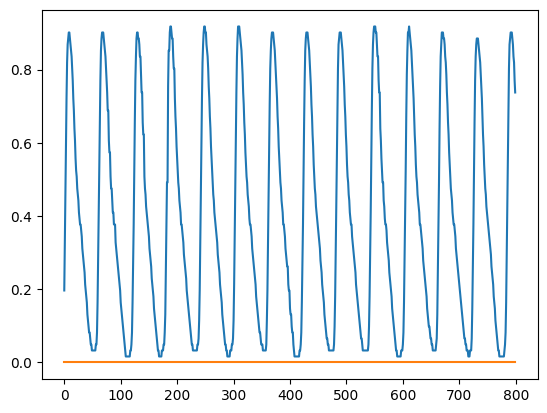

In [2]:
#Import_data
dataset = PPGDataset('D:\ppg_project\Data\data_train',label_list = {"Case":["PAC","PVC","PAC-nhip-doi","PAC-cap-doi","PVC-nhip-doi","PVC-cap-doi"],"Group": True})
print(dataset.count)

print(dataset[111][0].shape)
for i in [22]:
    plt.plot(dataset[i][0].numpy().flatten())
    plt.plot(dataset[i][1].numpy().flatten())

# plt.plot(dataset[0][1].numpy())
    plt.show()

Training

In [ ]:
# 1. Thiết lập thiết bị (device)
if torch.cuda.is_available():
    device = torch.device('cuda')
    print("Đang sử dụng GPU.")
else:
    device = torch.device('cpu')
    print("Đang sử dụng CPU.")

# 2. Xây dựng dictionary para tương thích với MultiResUnet
para_multires = {
    "Number class":         1,          # Vì dùng L1Loss (hồi quy), đầu ra là 1 kênh
    "Serie length":         800,        # Độ dài chuỗi đầu vào
    "Filter nums":          [32, 64, 128, 256], # Số bộ lọc cho mỗi tầng encoder
    "Respath kernel":       3,          # Kernel size cho ResPath (có thể tùy chỉnh)
    "Block kernel":         [3, 5, 7],  # Kernel sizes cho MultiResBlock
    "Filter rate":          [1.67, 0.333, 0.5], # Tỷ lệ filter đặc trưng của MultiResUnet
    "Pooling kernel":       [2] * 4,    # Kernel size cho MaxPool, 4 tầng
    "Transpose kernel":     [2] * 4     # Kernel size cho UpConv, 4 tầng
}

# 3. Khởi tạo mô hình, optimizer và criterion
# Đảm bảo bạn đã sửa lại lớp MultiResUnet để gỡ bỏ softmax
model = MultiResUnet(para_multires)
model.to(device) # Chuyển model sang GPU/CPU

optimizer = optim.Adam(model.parameters(), lr=0.0001)

# L1Loss là lựa chọn phù hợp cho bài toán hồi quy tín hiệu
criterion = nn.L1Loss()

# 4. Khởi tạo và chạy quy trình huấn luyện
# Giả định lớp k_fold_training đã được định nghĩa
builder = k_fold_training(dataset, 1, criterion=criterion)

# Bắt đầu huấn luyện
builder.training(model, device, optimizer, num_epochs=1500, batch=64, visualize=1)

print("Hoàn thành quá trình huấn luyện.")

Đang sử dụng CPU.
False
Iteration: 1/1500. loss_train: 0.9522312879562378. loss_val: 0
Iteration: 2/1500. loss_train: 0.9523671865463257. loss_val: 0
Iteration: 3/1500. loss_train: 0.9524352550506592. loss_val: 0
Iteration: 4/1500. loss_train: 0.95240718126297. loss_val: 0


KeyboardInterrupt: 

Performance

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\Admin\AppData\Local\Temp\ipykernel_28464\2692554754.py:2: SyntaxWarning: invalid escape sequence '\p'
  test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")


Max loss:  0.9298797
Mean loss:  0.2422321
Min loss:  0.059194162
Number of test:  84


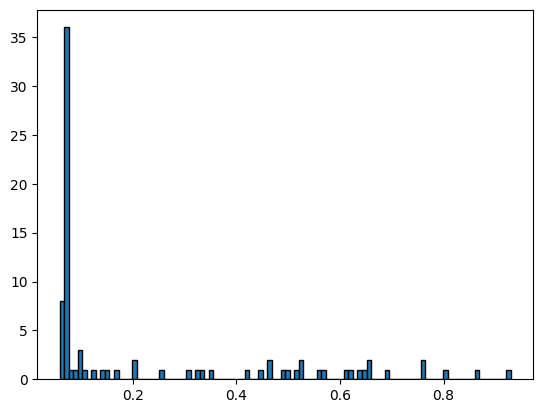

0.20585452


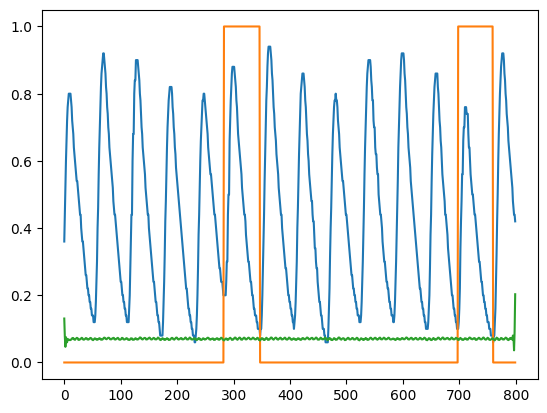

0.41955763


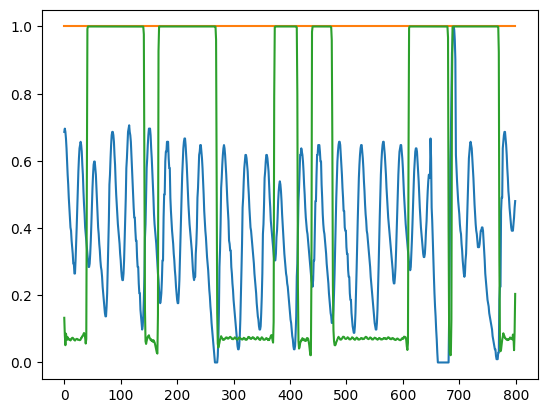

0.33309895


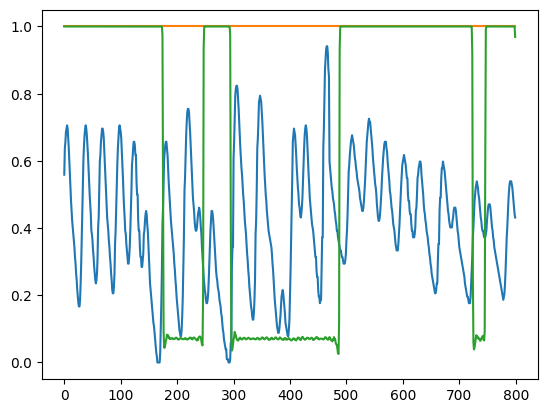

0.07073788


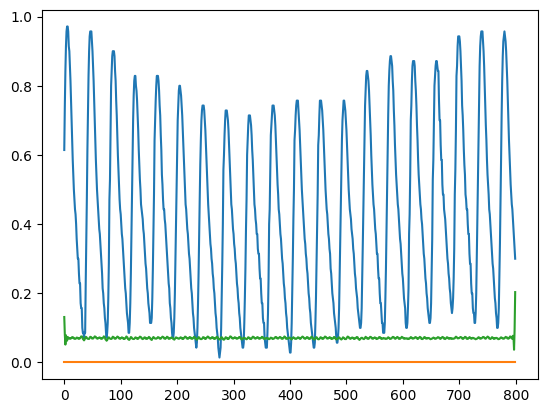

0.07108746


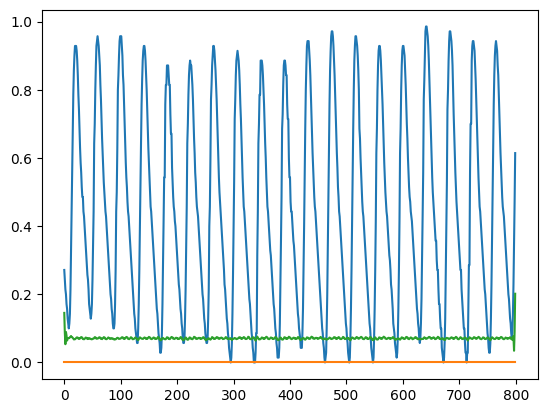

0.07082452


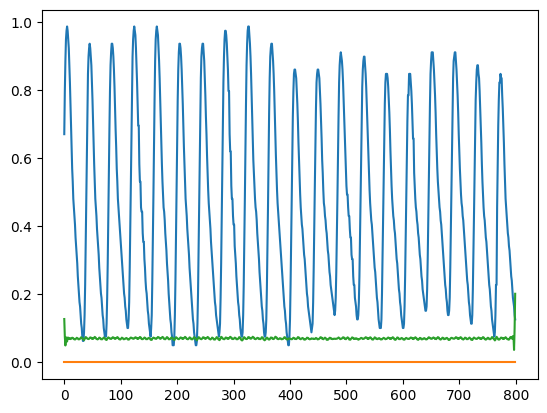

0.07093345


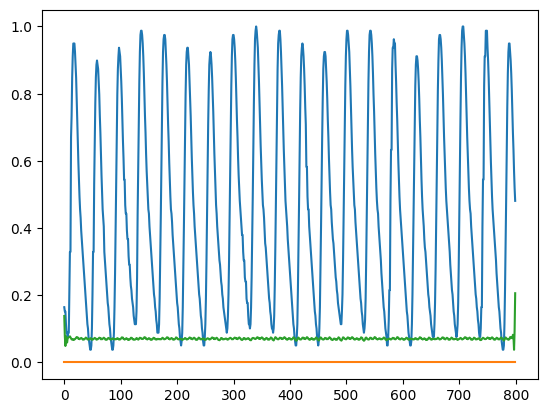

0.07079129


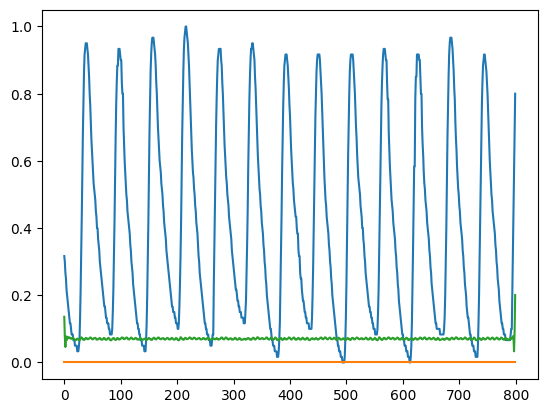

0.0706197


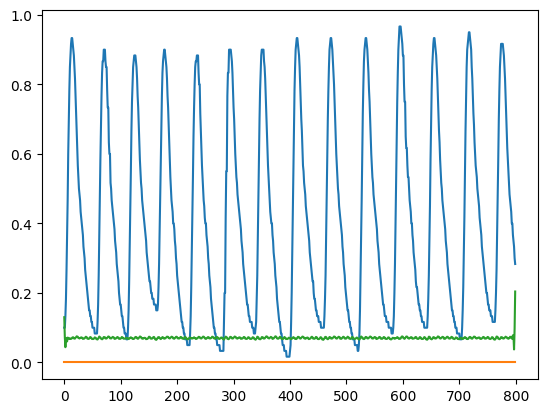

0.07085068


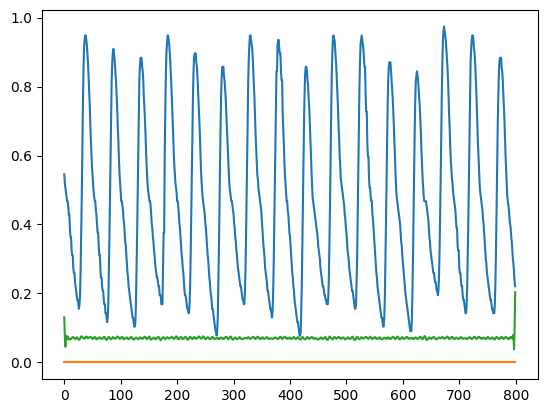

0.07091394


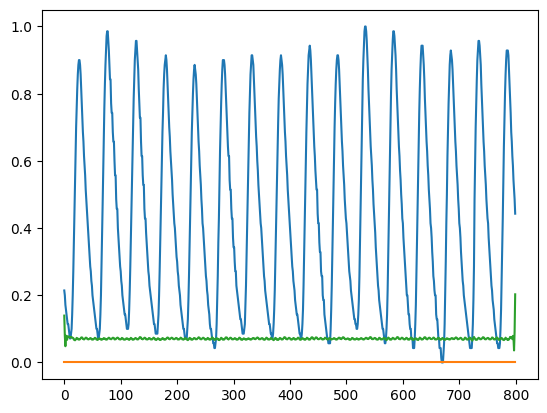

0.07094643


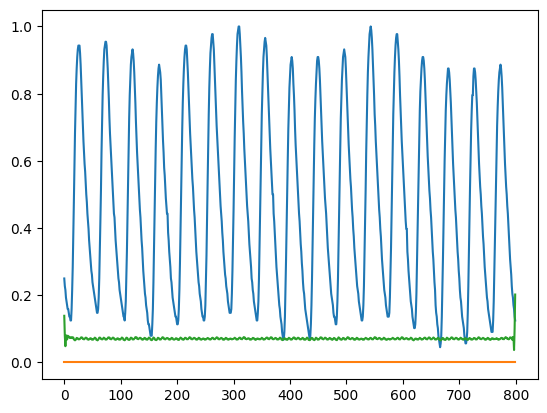

0.06454315


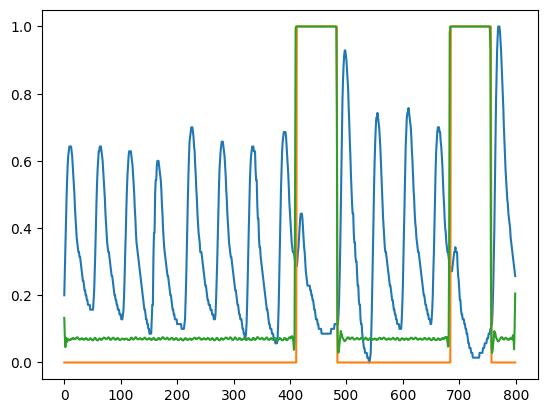

0.14789084


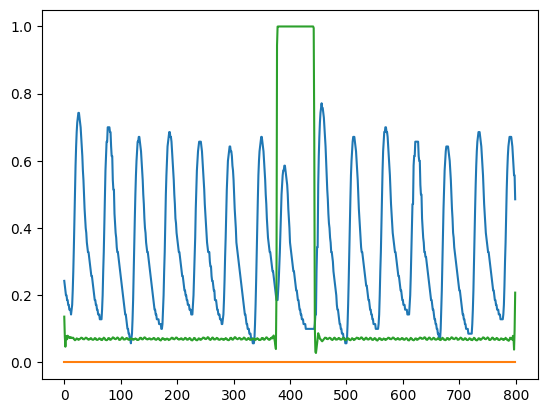

0.08308654


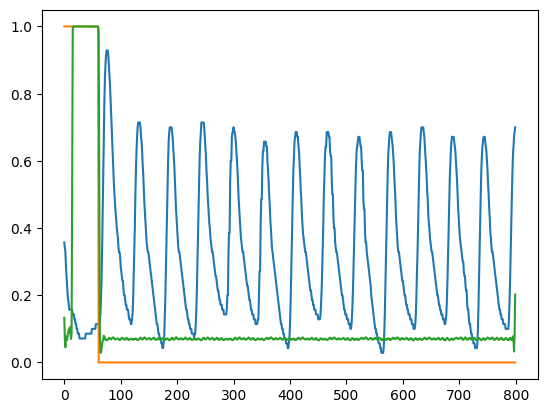

0.07037287


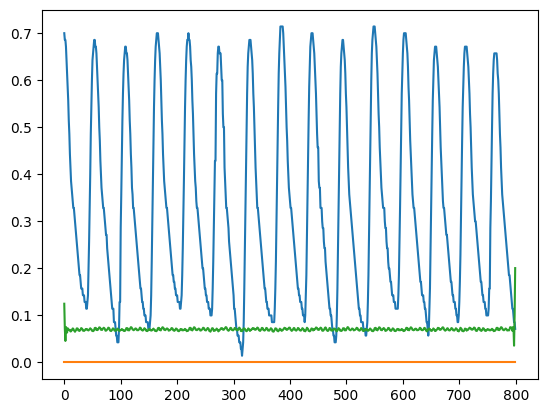

0.502487


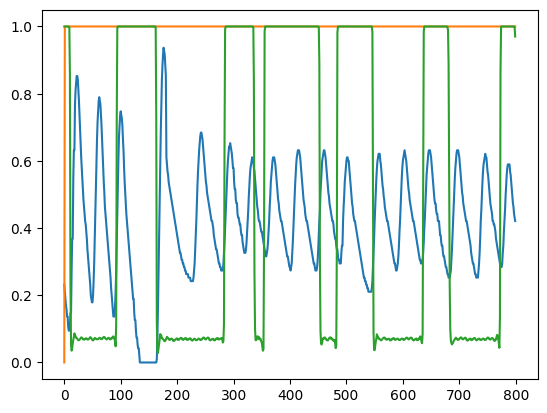

0.6148919


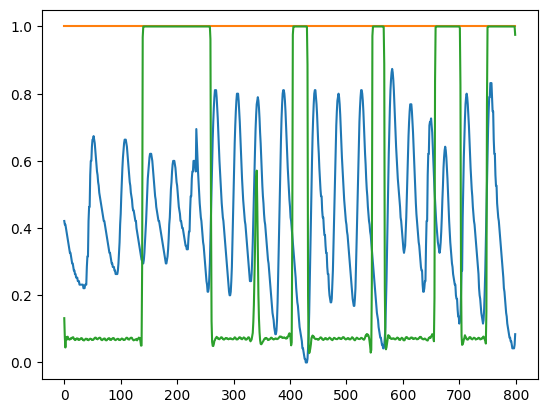

0.65406835


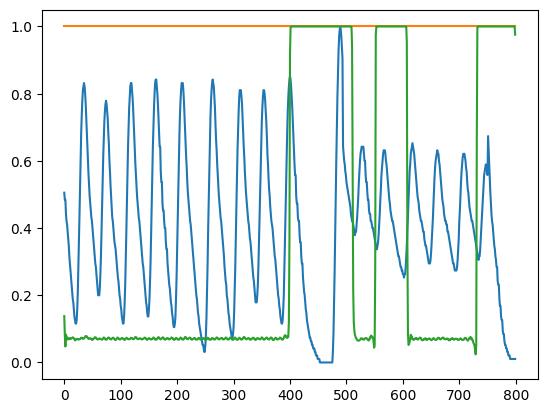

0.49057165


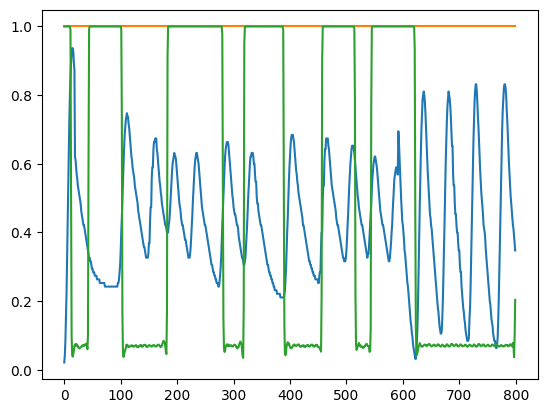

0.44406876


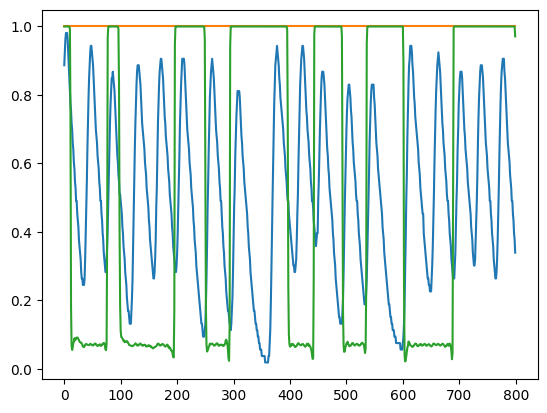

0.07072893


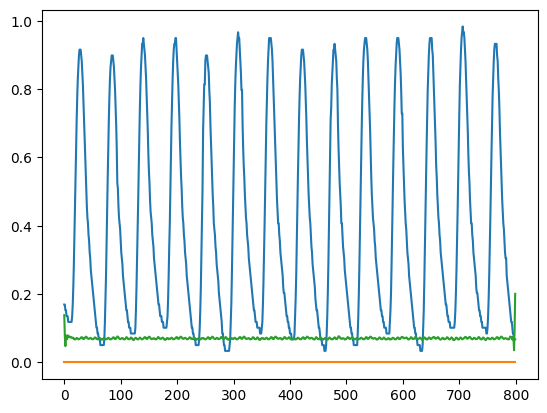

0.070765086


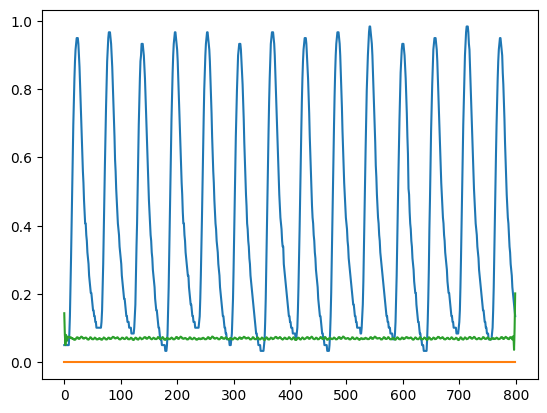

0.07095548


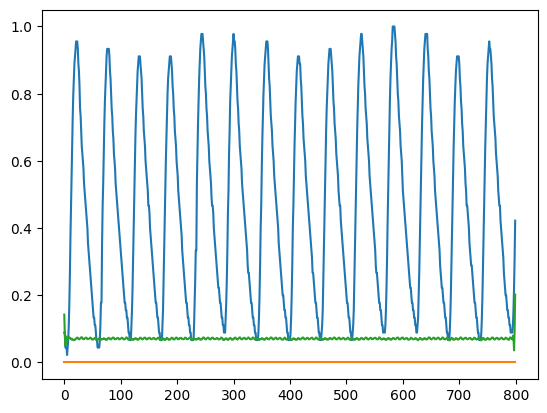

0.0705922


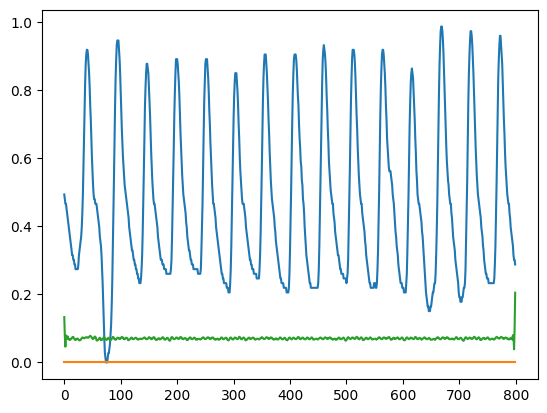

0.07058143


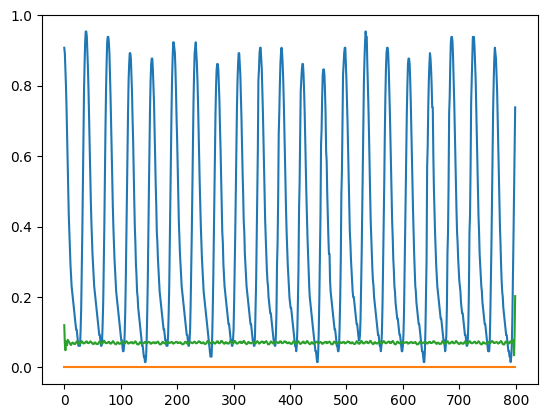

0.76245266


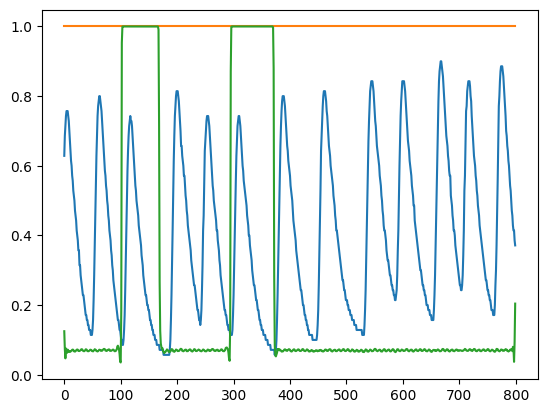

0.070883065


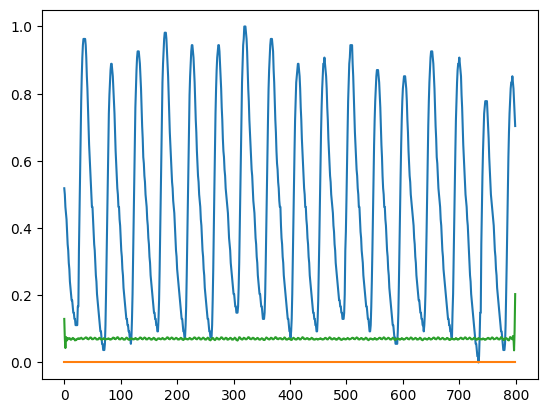

0.07083668


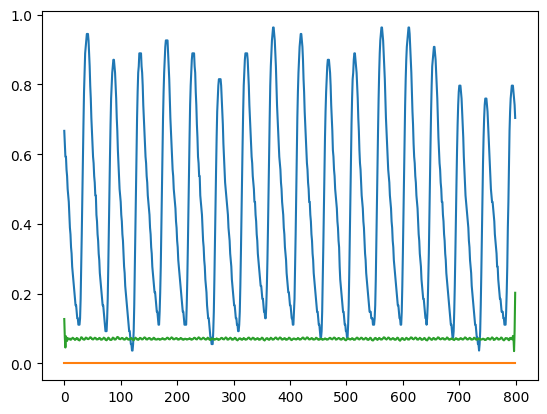

0.46507666


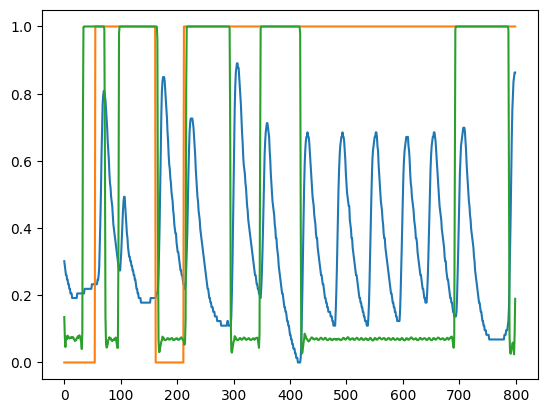

0.07082954


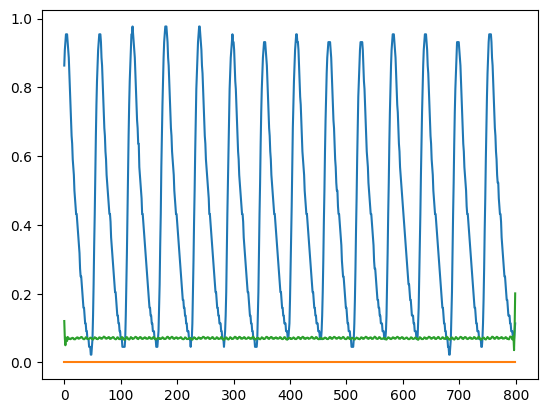

0.070607595


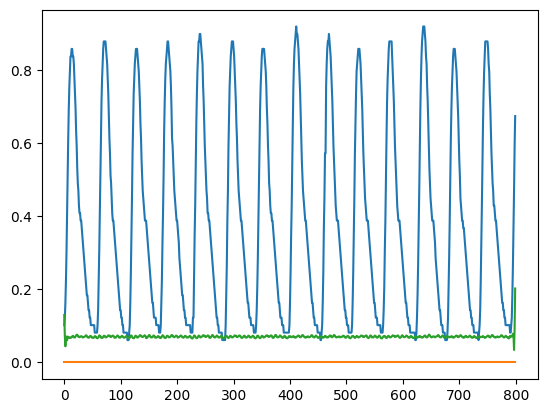

0.07094346


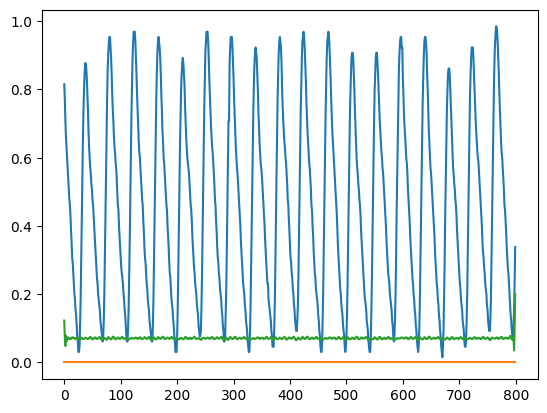

0.070669286


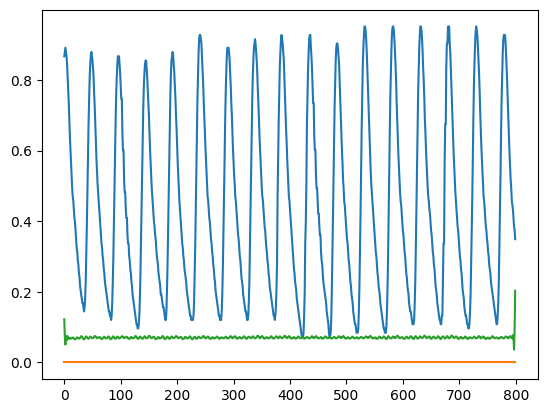

0.0707927


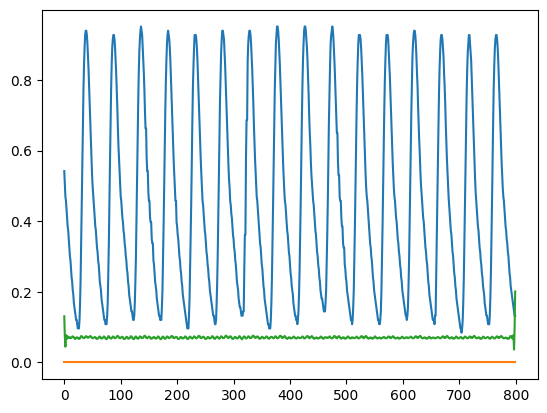

0.07081811


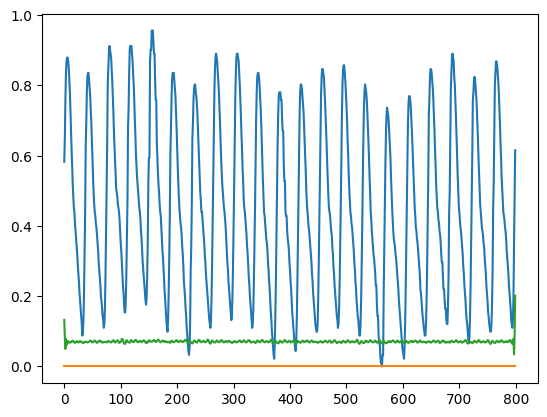

0.070733614


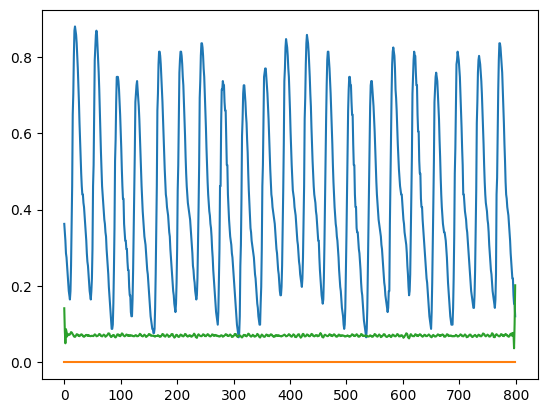

0.070543304


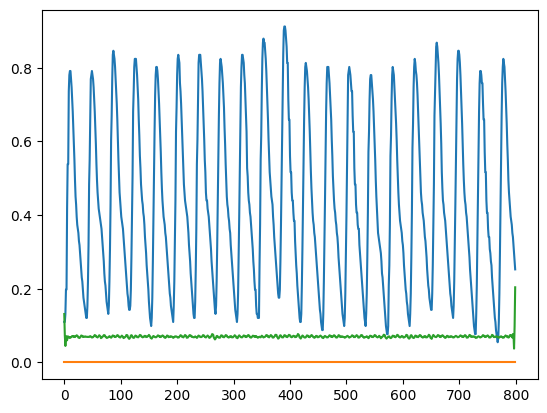

0.0701785


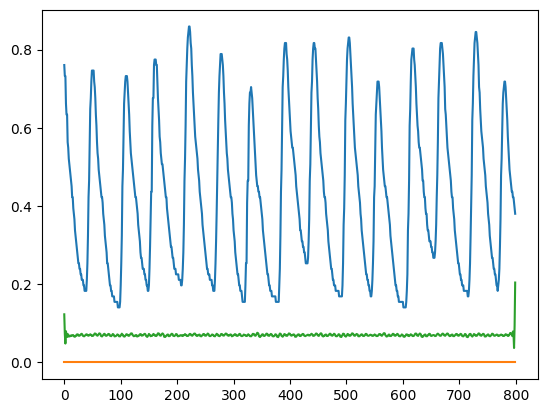

0.09491243


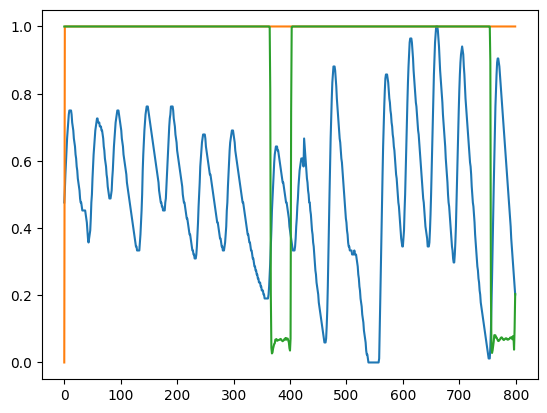

0.07058216


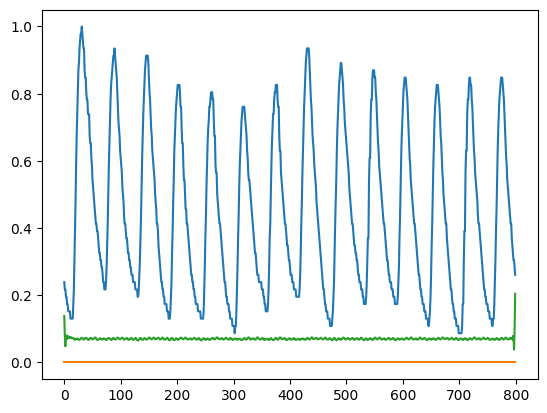

0.6892163


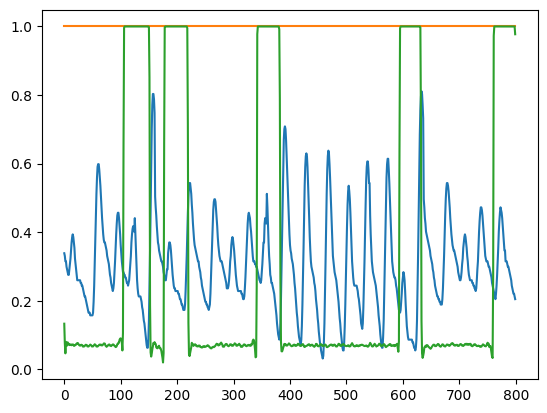

0.80122983


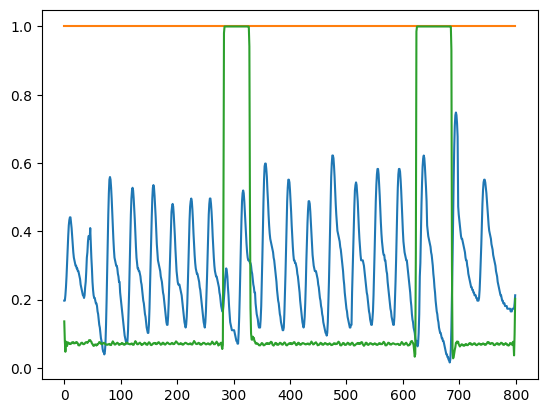

0.070035726


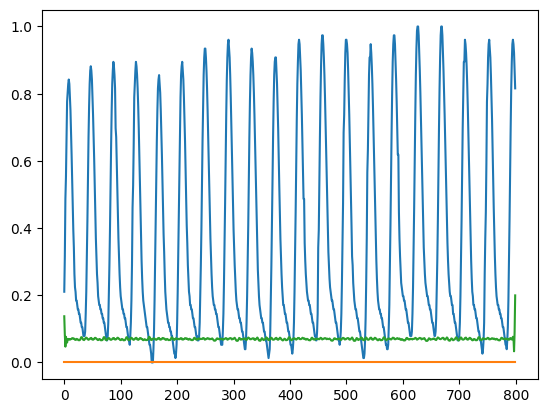

0.06924173


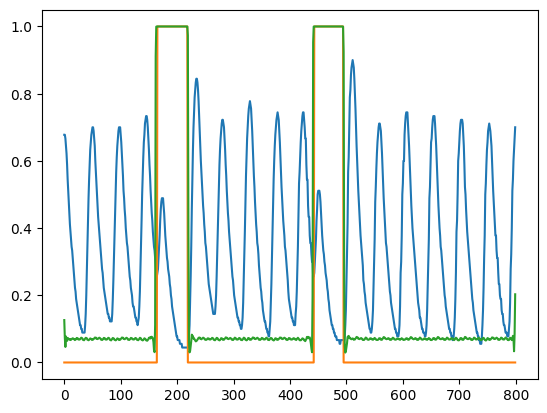

0.09995178


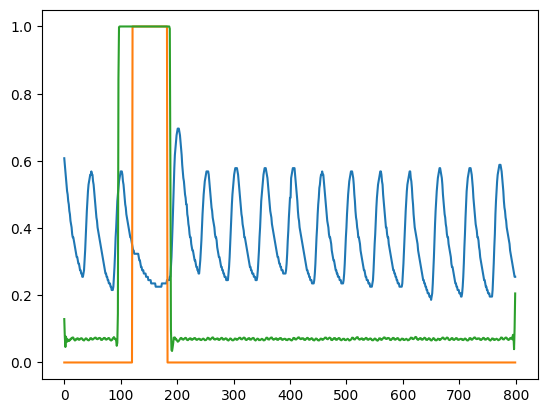

0.06595637


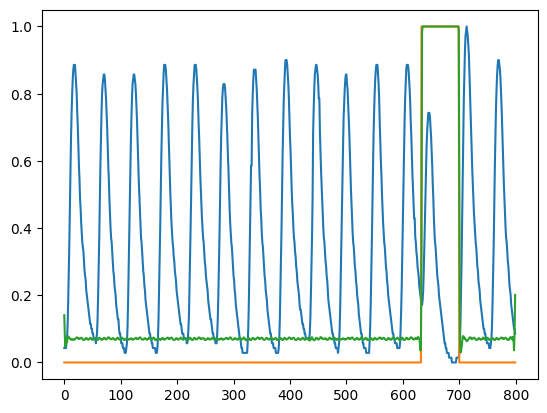

0.6398107


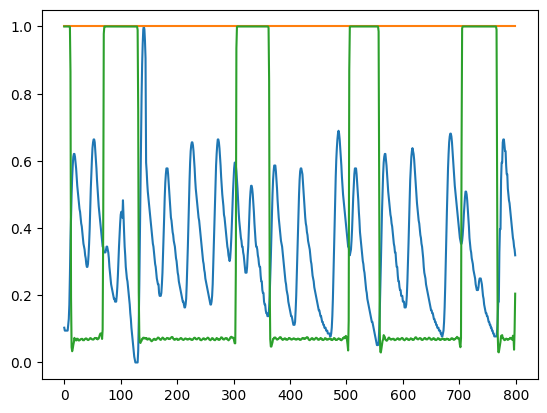

0.56416374


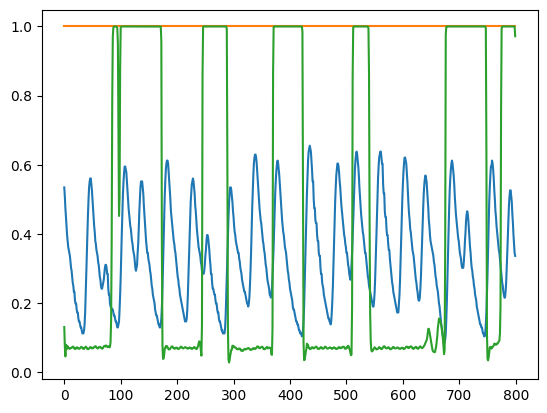

0.14047009


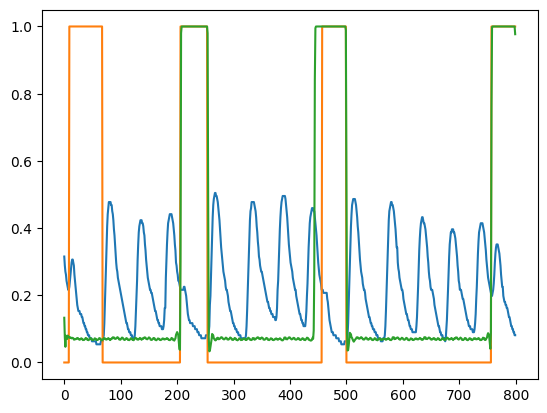

0.09119785


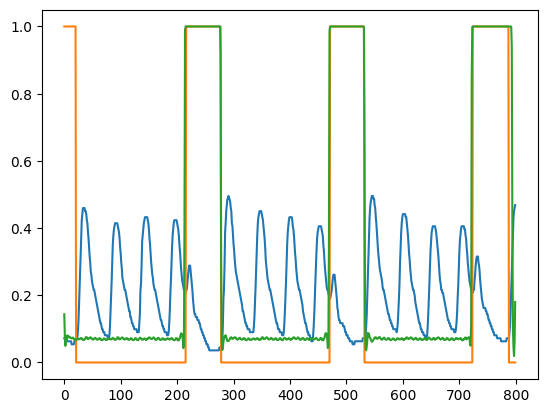

0.064920425


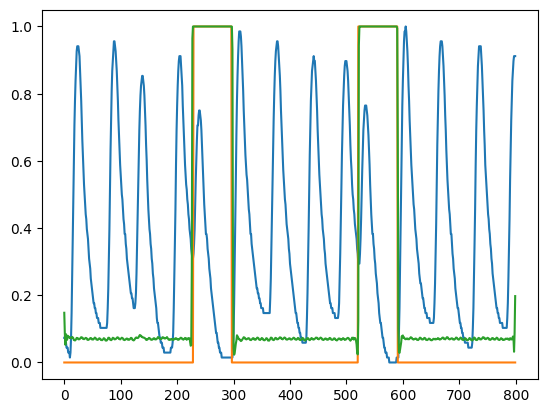

0.0706973


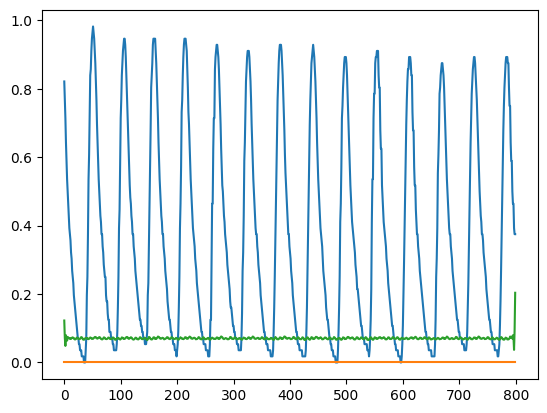

0.070946075


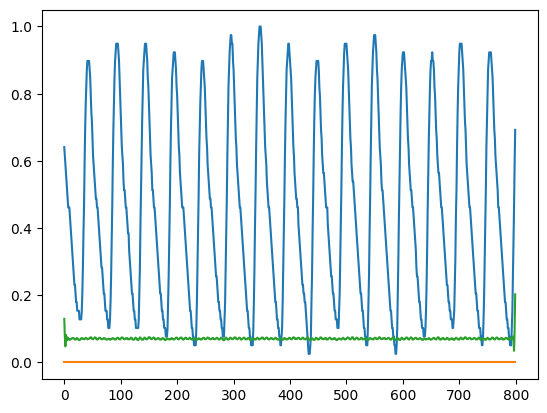

0.07079818


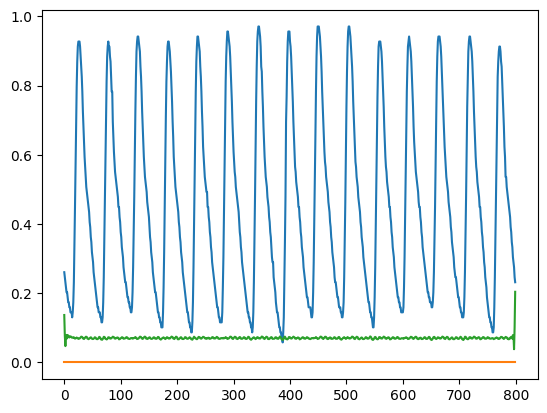

0.5269532


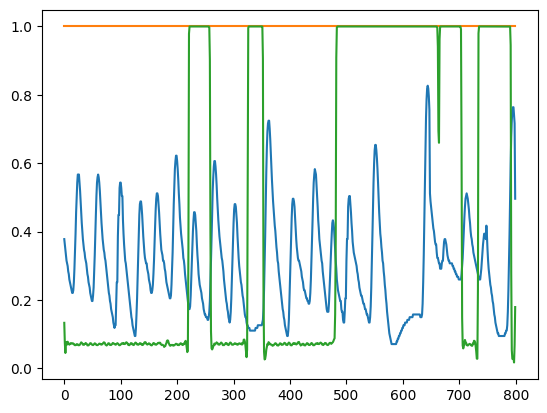

0.5168231


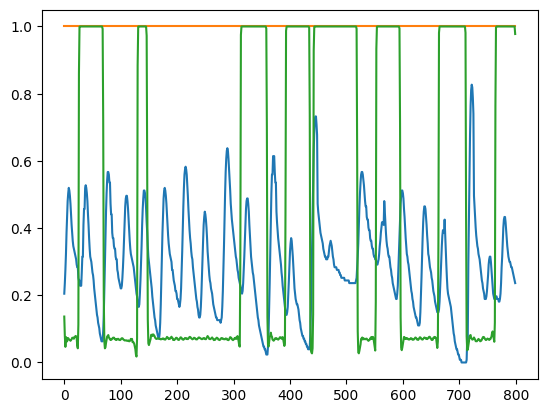

0.07072678


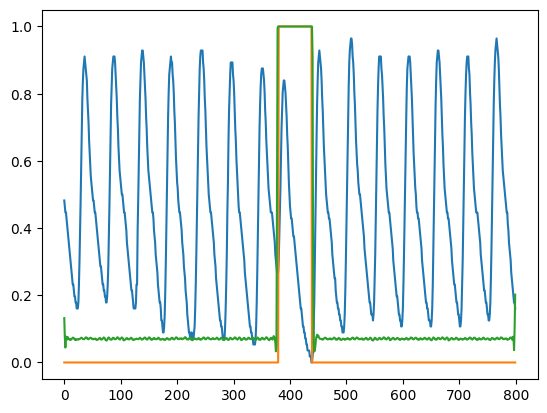

0.62020314


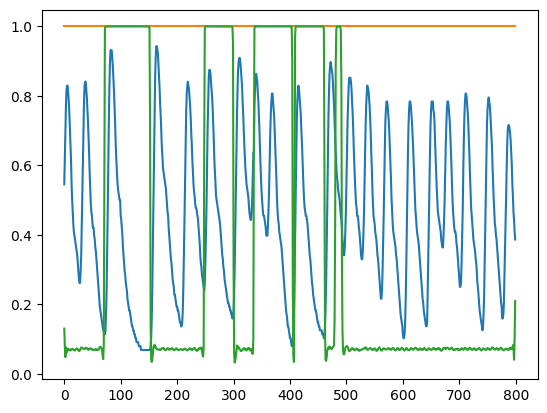

0.32444033


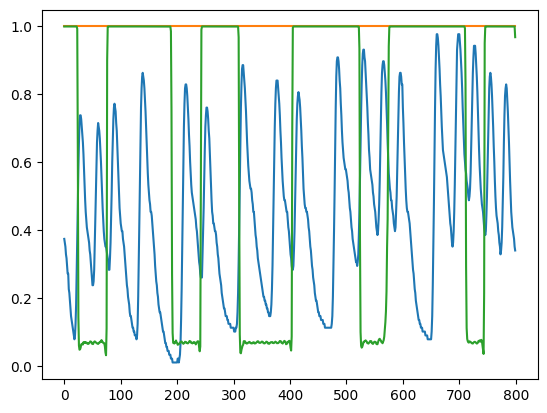

0.57131803


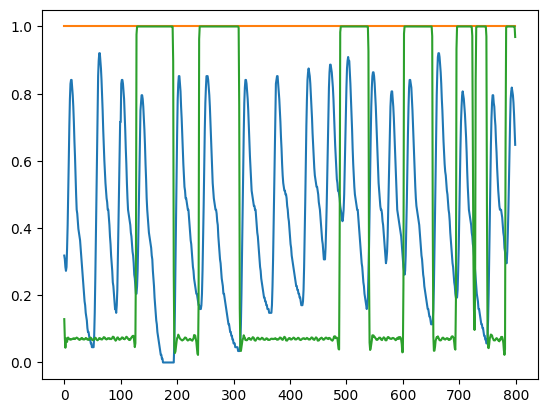

0.059194162


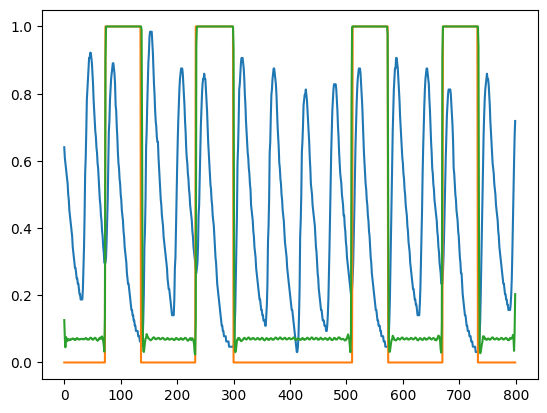

0.35476643


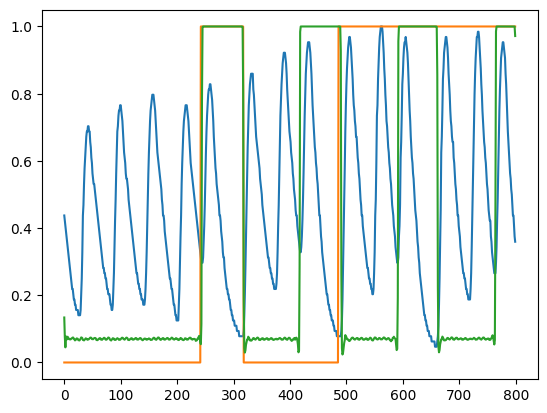

0.12684736


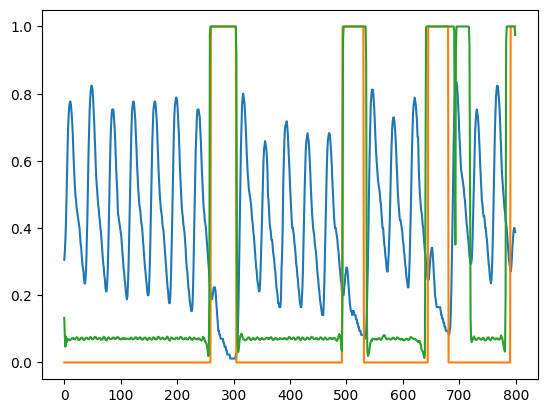

0.17125255


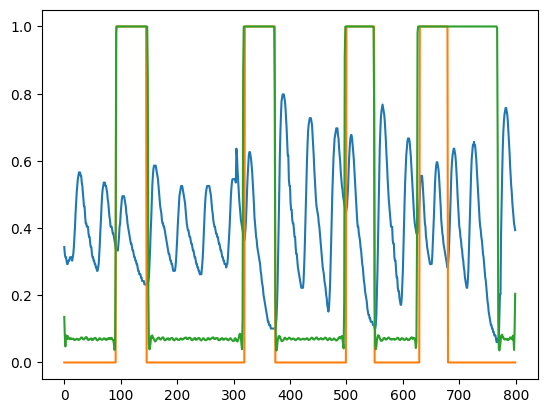

0.070532404


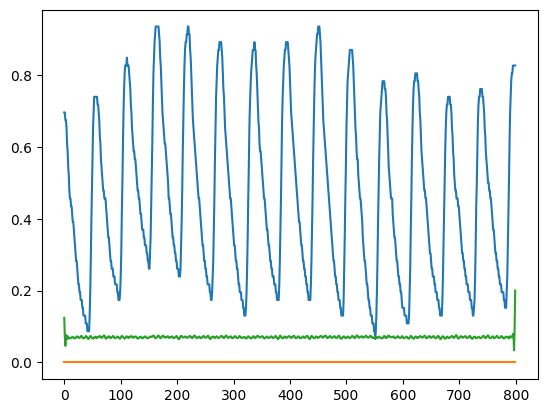

0.4606031


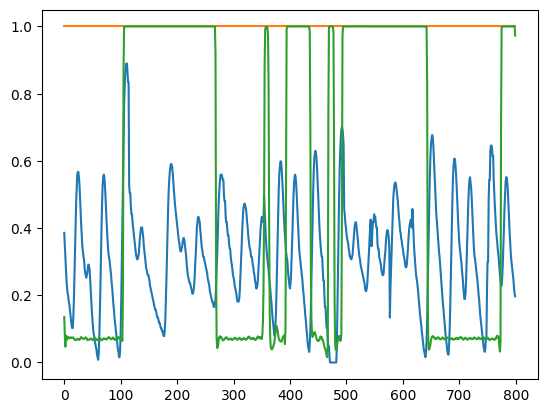

0.25559306


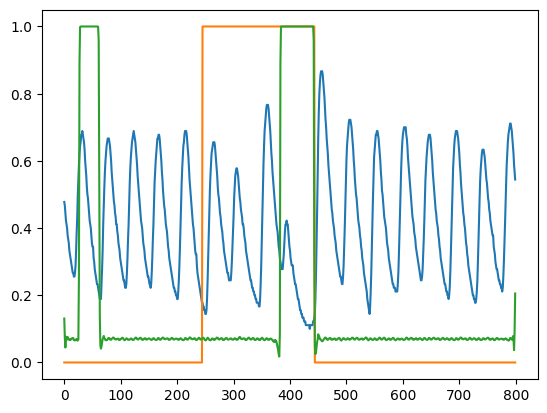

0.20485288


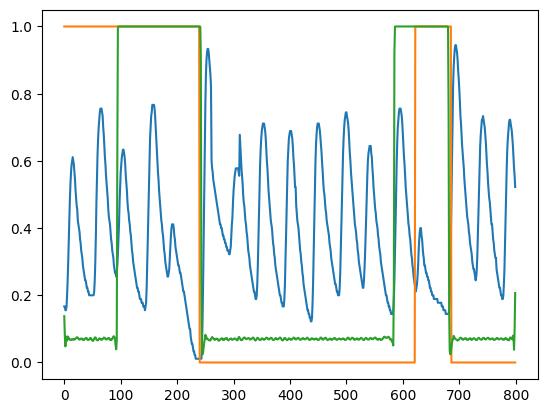

0.10965202


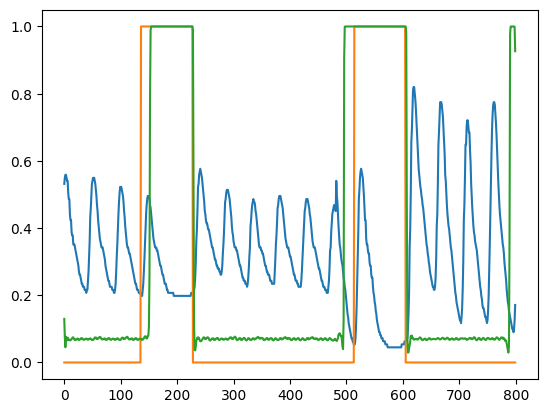

0.09983182


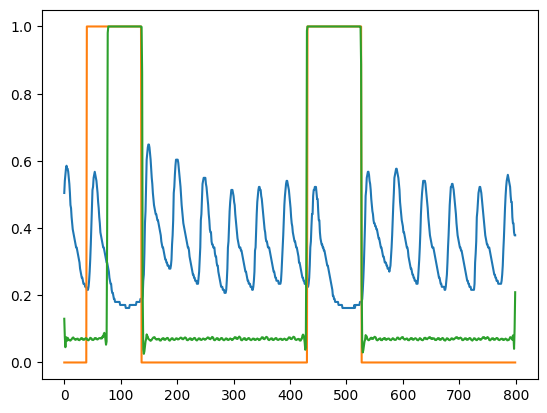

0.061084136


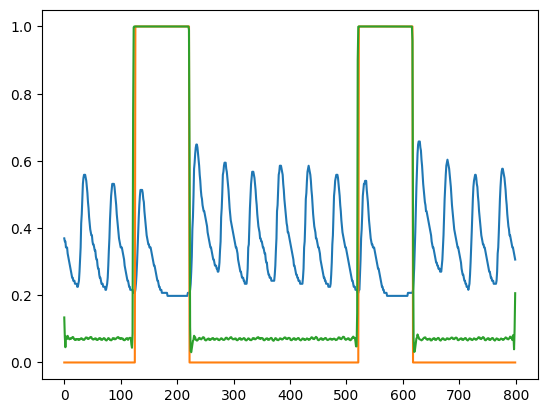

0.06873632


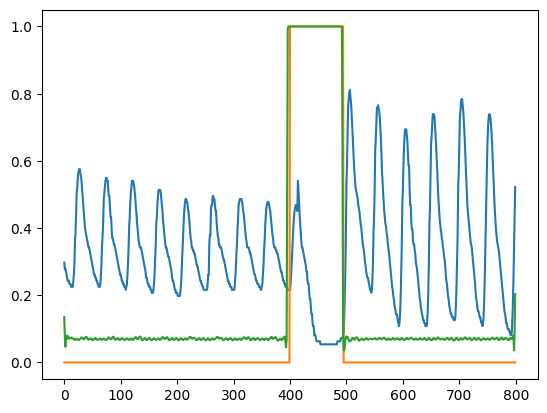

0.06711166


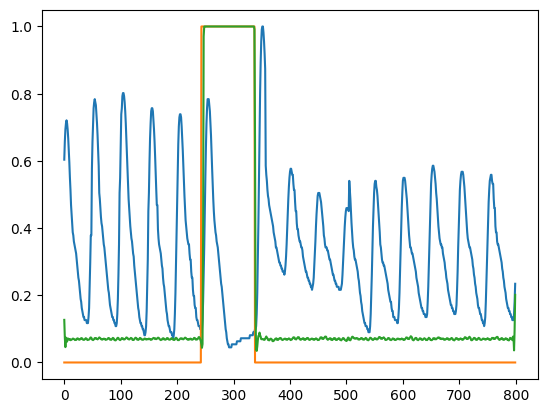

0.52893966


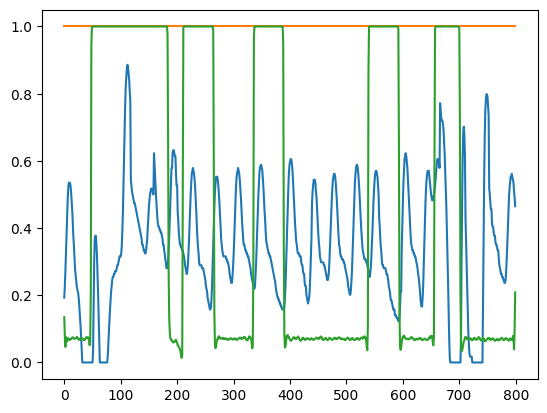

0.64849603


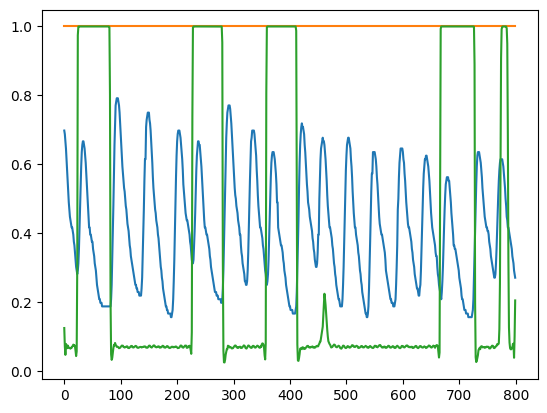

0.863651


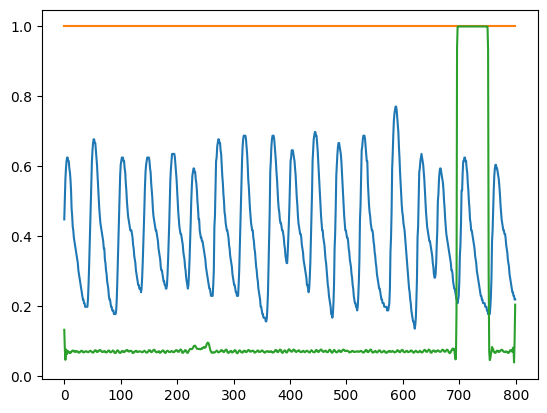

0.9298797


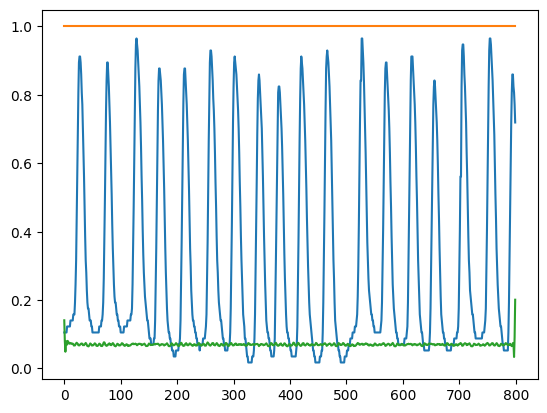

0.074787036


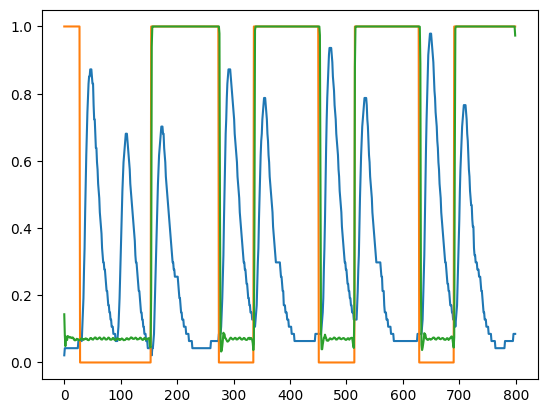

0.30621257


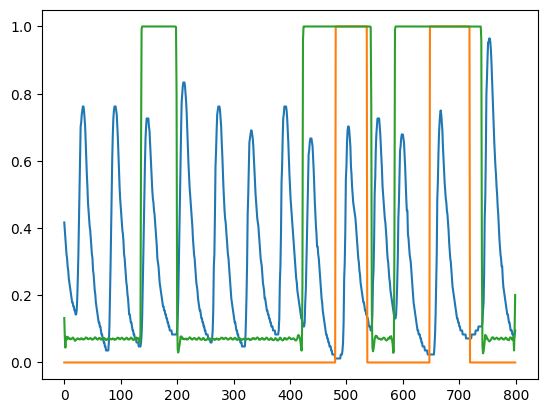

0.65813214


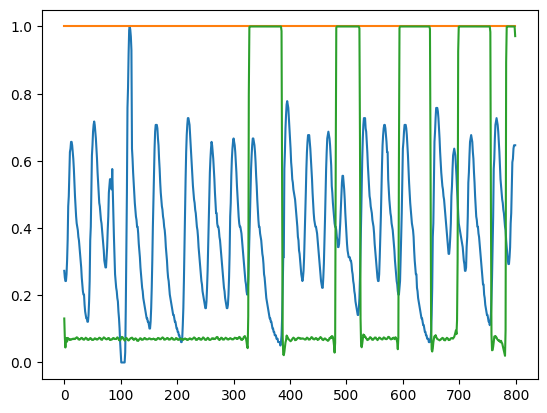

0.76334286


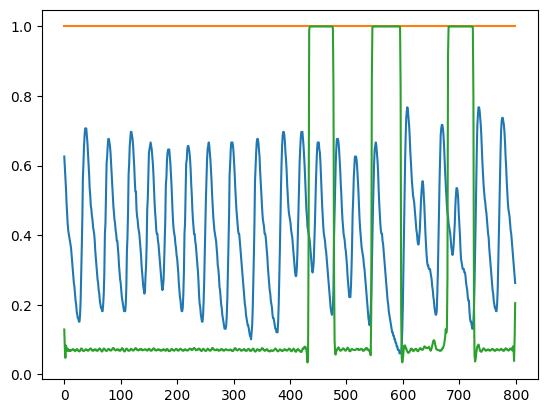

0.06689627


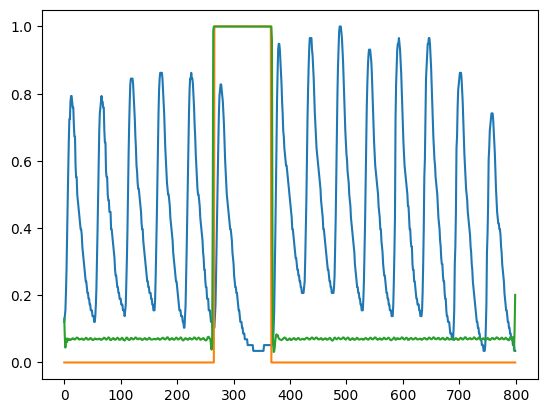

0.065321036


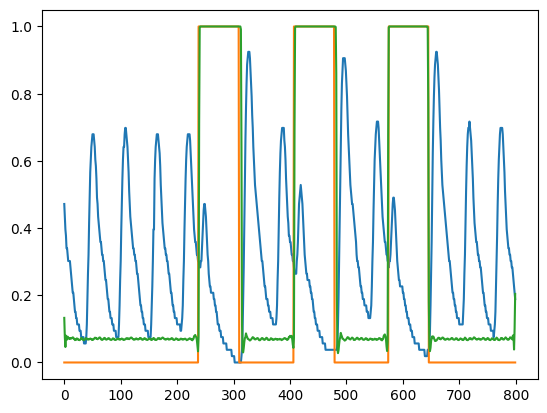

In [5]:
shower = performance()
test_data = PPGDataset('D:\ppg_project\Data\data_test',label_list = "AR")
shower.test(model,device,test_data,per_fnc = "series")
criterion = nn.L1Loss()
for i in range(len(test_data)):
    output = torch.stack([test_data[i][1]]).to(device)
    input = torch.stack([test_data[i][0]]).to(device)
    y_hat = model.forward(input)
    loss = criterion(y_hat,output)
    # if loss.cpu().detach().numpy()<0.3:
    print(loss.cpu().detach().numpy())
    plt.plot(input.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(output.cpu().detach().numpy().flatten()[0:1000])
    plt.plot(y_hat.cpu().detach().numpy().flatten()[0:1000])
    plt.show()